In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier

In [46]:

df = pd.read_csv('C:/Users/pinki/OneDrive/Desktop/Machine_learning_indetails/dataset/Cardiovascular_Disease.csv')

In [47]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [48]:

# Convert age from days to years
df['age'] = round(df['age'] / 365)

In [49]:
# Remove abnormal blood pressure values
bp_filter = (df['ap_hi'].between(90, 200)) & (df['ap_lo'].between(40, 90))
df = df[bp_filter]

In [50]:
# Remove abnormal weight values
weight_filter = (df['weight'] >= 40) & (df['weight'] <= 140)
df = df[weight_filter]

In [51]:
height_filter = df['height'] >= 120
df = df[height_filter]

In [52]:

# Display Min and Max Values
columns = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

for col in columns:
    print(col)
    print('-' * 20)
    print(f'Max Value : {df[col].max()}')
    print(f'Min Value : {df[col].min()}')
    print('-' * 20)

age
--------------------
Max Value : 65.0
Min Value : 30.0
--------------------
height
--------------------
Max Value : 207
Min Value : 120
--------------------
weight
--------------------
Max Value : 140.0
Min Value : 40.0
--------------------
ap_hi
--------------------
Max Value : 200
Min Value : 90
--------------------
ap_lo
--------------------
Max Value : 90
Min Value : 40
--------------------


In [53]:
# Take Sample Data
df_sample = df.sample(n=5000, random_state=42)

In [54]:
features = [
    'age', 'gender', 'height', 'weight',
    'ap_hi', 'ap_lo', 'cholesterol',
    'gluc', 'smoke', 'alco', 'active'
]

In [55]:
target = 'cardio'

In [56]:
X = df_sample[features]
y = df_sample[target]

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [58]:
# Scaling is not required for Decision Tree,
# but useful for XGBoost consistency
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [59]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

In [60]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [61]:
dt_pred = dt_model.predict(X_test)

In [62]:
dt_pred

array([0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1,

In [63]:
dt_accuracy = accuracy_score(y_test, dt_pred)
print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

Decision Tree Accuracy: 0.6800


In [64]:
cr = classification_report(y_test, dt_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.66      0.79      0.72       520
           1       0.71      0.56      0.63       480

    accuracy                           0.68      1000
   macro avg       0.69      0.68      0.67      1000
weighted avg       0.69      0.68      0.68      1000



In [65]:
cm = confusion_matrix(y_test, dt_pred)
print(cm)

[[412 108]
 [212 268]]


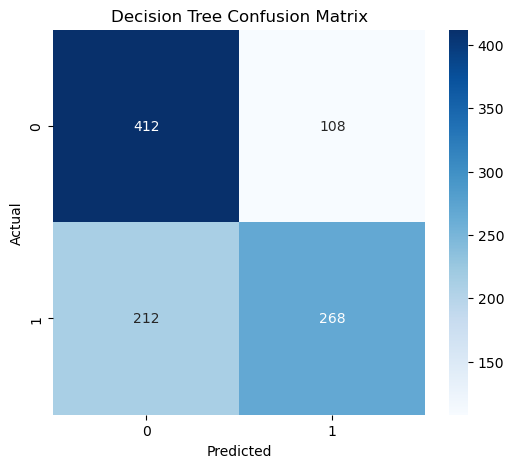

In [66]:
plt.figure(figsize=(6,5))
sns.heatmap(cm ,annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# XGBoost Classifier

In [70]:
X_train_scale = np.array(X_train_scale)
X_test_scale = np.array(X_test_scale)

In [71]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

In [72]:
xgb_model.fit(X_train_scale, y_train)

c:\Users\pinki\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:50:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [73]:
xgb_pred = xgb_model.predict(X_test_scale)

In [74]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)

In [75]:
print(f"\nXGBoost Accuracy: {xgb_accuracy:.4f}")


XGBoost Accuracy: 0.6950


In [76]:
# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, xgb_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.69      0.76      0.72       520
           1       0.71      0.62      0.66       480

    accuracy                           0.69      1000
   macro avg       0.70      0.69      0.69      1000
weighted avg       0.70      0.69      0.69      1000



In [77]:
xgb_cm = confusion_matrix(y_test, xgb_pred)
print(xgb_cm)

[[395 125]
 [180 300]]


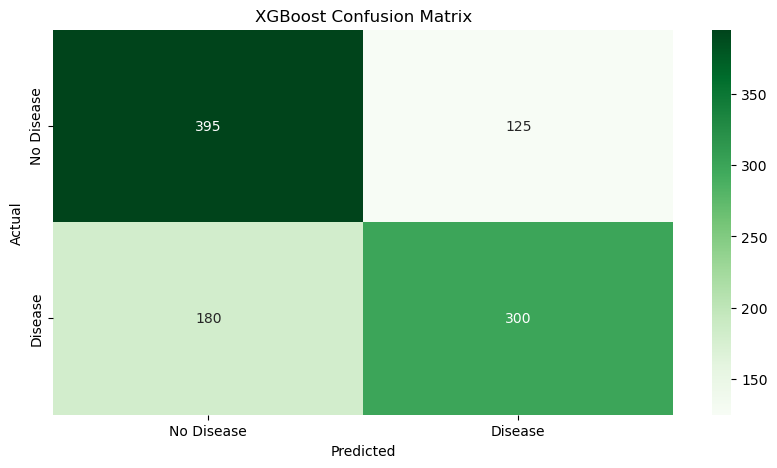

In [81]:
# Heatmap
plt.figure(figsize=(10,5))
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Greens',    xticklabels=['No Disease', 'Disease'],
    yticklabels=['No Disease', 'Disease'])

plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()